<a href="https://colab.research.google.com/github/marinhotechdev/InteligenciaArtificial/blob/main/S03_IA_ADS_live.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Importar as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [12]:
# Preparação do dataset
df = pd.read_csv('alunos.csv')
df.head(3)

,horas_estudo,faltas,nota
0,1,18,2.5
1,2,17,3.0
2,2,15,3.5


In [13]:
# Criação de uma nova variável (feature engineering)
df["aprovado"] = df["nota"] >= 6
df.tail()

,horas_estudo,faltas,nota,aprovado
38,11,10,8.0,True
39,12,9,8.4,True
40,13,8,8.8,True
41,14,7,9.1,True
42,15,6,9.5,True


In [14]:
# Definir as entradas e a saída
X = df[['horas_estudo', 'faltas']] # entrada
y = df['aprovado'] # saída

# Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


In [15]:
# Treinamento do modelo (Regressão logística)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

LogisticRegression()

In [16]:
# Previsões do modelo
y_pred = modelo.predict(X_test)
print(f"Previsões")
print(f"{y_pred}")
print(f"{y_test}")

Previsões
[ True  True  True  True  True  True False  True  True False False  True
 False]
37     True
24     True
25     True
36     True
34     True
39     True
4     False
12     True
8     False
3     False
6     False
27     True
31    False
Name: aprovado, dtype: bool


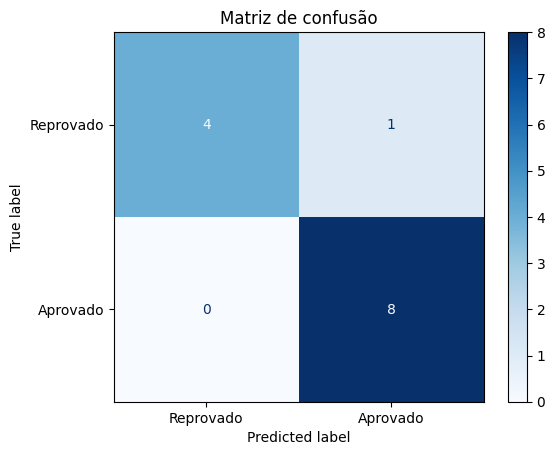

In [17]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
# print(f"Matriz de confusão")
# print(f"{cm}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Reprovado", "Aprovado"],
    cmap="Blues"
)
plt.title("Matriz de confusão")
plt.show()



In [18]:
# Métricas de avaliação do modelo
# Acurácia
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc}")

# Relatório de classificação (classification report)
print(f"Relatório de classificação")
print(classification_report(y_test, y_pred))

Acurácia: 0.9230769230769231
Relatório de classificação
              precision    recall  f1-score   support

       False       1.00      0.80      0.89         5
        True       0.89      1.00      0.94         8

    accuracy                           0.92        13
   macro avg       0.94      0.90      0.92        13
weighted avg       0.93      0.92      0.92        13



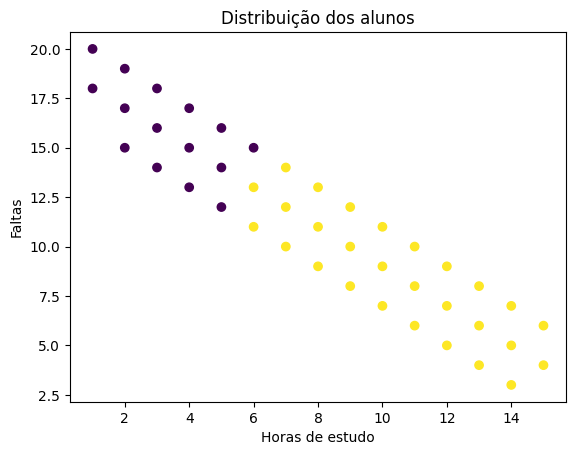

In [19]:
# Visualização dos dados
plt.scatter(df['horas_estudo'], df['faltas'], c=df['aprovado'])
plt.xlabel("Horas de estudo")
plt.ylabel("Faltas")
plt.title("Distribuição dos alunos")
plt.show()

In [20]:
# Teste individual de previsão
novo_aluno = pd.DataFrame(
    {
        "horas_estudo" : [20],
        "faltas" : [15]
    }
)

previsao = modelo.predict(novo_aluno)
print(f"Previsão para o novo aluno: {previsao}")

Previsão para o novo aluno: [ True]
